# Why Clearwater park buffers are not park acreage

The checked `clearwater-park-buffers` layer contains **buffer polygons around sites**, not park property boundaries. This story compares each feature's source `Acreage` attribute with the area of its buffer polygon and checks how the difference varies by `Buf_Distance`.

**Source:** [City of Clearwater park-buffer layer](https://gis.myclearwater.com/arcgis/rest/services/ArcGISMapServices/Clearwater_Park_Buffers/MapServer/0). Run with an R kernel and `tampaBayOpenData`. The published layer can change between runs.

In [1]:
library(tampaBayOpenData)

info <- tbod_dataset_info("clearwater-park-buffers")
stopifnot(as.integer(info$spatial_reference$wkid) == 2882L)
cat(info$publisher, "|", info$title, "\nSource:", info$source_url,
    "\nLayer CRS: EPSG:", info$spatial_reference$wkid, "\n", sep = "")

City of Clearwater|Clearwater park buffers
Source:https://gis.myclearwater.com/arcgis/rest/services/ArcGISMapServices/Clearwater_Park_Buffers/MapServer/0
Layer CRS: EPSG:2882


## Retrieve and check completeness

The package fetches all matching rows and validates the object-ID manifest. We request attributes only; `Shape_Area` is the source's area field for the **buffer geometry**. EPSG:2882 uses US survey feet, so its squared coordinate units can be converted to acres with 43,560 square feet per acre.

In [2]:
buffers <- tbod_get_dataset(
  "clearwater-park-buffers",
  fields = c("OBJECTID", "Site_Name", "Type", "Acreage",
             "Buf_Distance", "BUFF_DIST", "Shape_Area"),
  spatial = FALSE, limit = Inf
)
p <- tbod_provenance(buffers)
stopifnot(isTRUE(p$complete), p$matched_rows == nrow(buffers),
          p$returned_rows == nrow(buffers), !anyDuplicated(buffers$OBJECTID))
print(data.frame(retrieved_at_utc = format(p$retrieved_at, tz = "UTC"),
                 matched_rows = p$matched_rows, returned_rows = p$returned_rows,
                 complete = p$complete, integrity = p$integrity))

     retrieved_at_utc matched_rows returned_rows complete     integrity
1 2026-10-06 22:38:13          126           126     TRUE full-manifest


## Compare site and buffer area

The service has two distance fields. We check that they agree, then divide each buffered polygon's square-foot area by the publisher's acreage attribute. `Acreage` appears to describe the underlying site: for the 1-foot buffers, the two measures are close. This interpretation is an inference from field names and values, not a published field definition.

In [3]:
stopifnot(isTRUE(all.equal(as.numeric(buffers$Buf_Distance),
                           as.numeric(buffers$BUFF_DIST))))
usable <- !is.na(buffers$Acreage) & !is.na(buffers$Shape_Area) &
          !is.na(buffers$Buf_Distance) & buffers$Acreage > 0 &
          buffers$Shape_Area > 0
stopifnot(any(usable))
distance <- factor(buffers$Buf_Distance[usable],
                   levels = sort(unique(buffers$Buf_Distance[usable])))
area_ratio <- (buffers$Shape_Area[usable] / 43560) / buffers$Acreage[usable]
by_distance <- data.frame(
  buffer_distance_ft = as.numeric(levels(distance)),
  sites = as.integer(table(distance)),
  median_site_acres = round(unname(tapply(buffers$Acreage[usable], distance, median)), 2),
  median_buffer_to_site_area = round(unname(tapply(area_ratio, distance, median)), 1)
)
print(by_distance, row.names = FALSE)
cat("Rows excluded for missing or nonpositive areas:", sum(!usable), "\n")

 buffer_distance_ft sites median_site_acres median_buffer_to_site_area
                  1    42             20.97                        1.0
               5280    57              1.88                     1153.4
              10560    27             15.78                      567.9


Rows excluded for missing or nonpositive areas: 0 


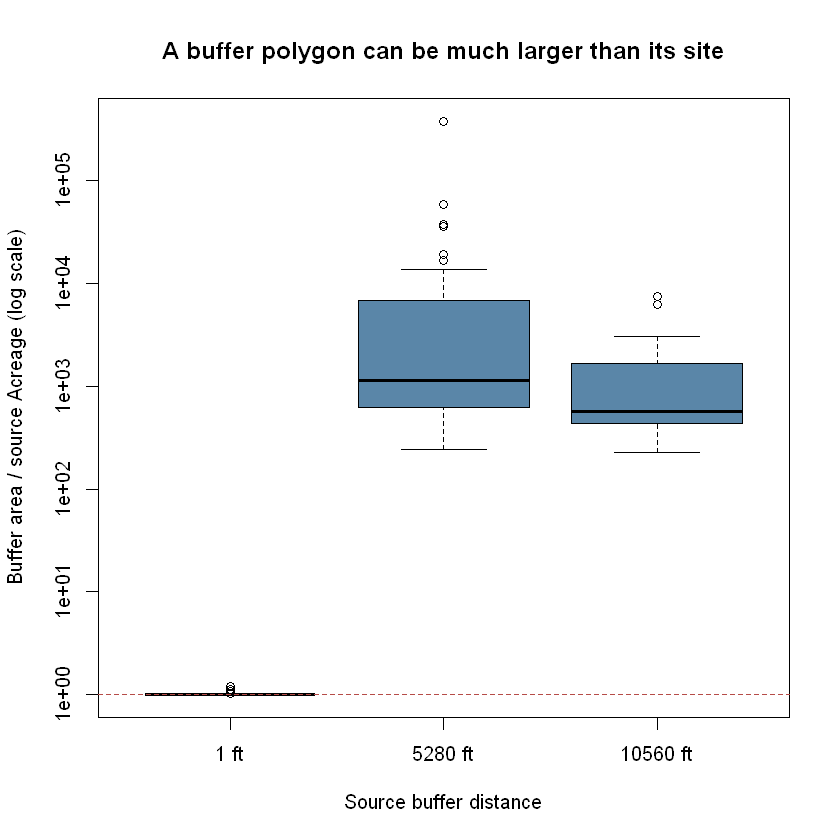

In [4]:
boxplot(area_ratio ~ distance, log = "y", col = "#5A86A8",
        names = paste0(levels(distance), " ft"),
        xlab = "Source buffer distance", ylab = "Buffer area / source Acreage (log scale)",
        main = "A buffer polygon can be much larger than its site")
abline(h = 1, lty = 2, col = "#B64C48")

The 1-foot distance is effectively a near-boundary buffer, while 5,280 and 10,560 feet are about one and two miles. The one- and two-mile polygons can overlap each other, so summing their areas would **not** give park acreage or unique area served. Distances describe the published geometry; they do not measure walkable access or travel time.